# **DATASET INFORMATION**

This dataset provides an in-depth overview of transaction behavior and financial activity patterns, making it highly suitable for exploring fraud detection, anomaly identification, and product recommendation. The dataset contains **2,512 transaction records**, covering various attributes related to transactions, customer demographics, and usage patterns.

Each entry provides comprehensive insights into transaction behavior, enabling analysis for financial security as well as the development of predictive models.

## Key Features

- **`TransactionID`**: A unique alphanumeric identifier for each transaction.  
- **`AccountID`**: A unique ID for each account, where one account can have multiple transactions.  
- **`TransactionAmount`**: The transaction value in currency, ranging from small expenses to large purchases.
- **`TransactionDate`**: The date and time when the transaction occurred.
- **`TransactionType`**:The type of transaction, either `'Credit'` or `'Debit'`.  
- **`Location`**: The geographic location where the transaction occurred (city names in the United States).  
- **`DeviceID`**: The ID of the device used to perform the transaction.
- **`IP Address`**: The IPv4 address used during the transaction, which may vary across different transactions for the same account.
- **`MerchantID`**: A unique merchant identifier, useful for identifying common merchants and detecting unusual transaction patterns.
- **`AccountBalance`**: The account balance after the transaction is completed.
- **`PreviousTransactionDate`**: The date of the previous transaction on the account, useful for calculating transaction frequency.
- **`Channel`**:The transaction channel, such as `Online`, `ATM`, or `Branch`.
- **`CustomerAge`**: The age of the account holder.
- **`CustomerOccupation`**: The customer’s occupation, such as `Doctor`, `Engineer`, `Student`, or `Retired`.  
- **`TransactionDuration`**: The duration of the transaction (in seconds).
- **`LoginAttempts`**:The number of login attempts before the transaction. A high number of attempts may indicate suspicious activity.


## **1. Library**


In [1]:
import numpy as np
import pandas as pd  # Data manipulation and analysis
import matplotlib.pyplot as plt  # Graphic visualization
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer  # Visualization for Elbow Method

from sklearn.cluster import KMeans, DBSCAN  # KMeans and DBSCAN algorithm for clustering
from sklearn.metrics import silhouette_score  # Clustering result's evaluation
from sklearn.preprocessing import MinMaxScaler, LabelEncoder # Scalling and Encoding
from sklearn.decomposition import PCA  # Principal Component Analysis (Reduce features)

import joblib
from google.colab import files

## **2. Load Dataset**
   

In [2]:
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)

In [3]:
# Preview the dataset
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [4]:
# Check dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Generate summary statistics for numerical features
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


## **3. Exploratory Data Analysis (EDA)**

### Correlation Between Features

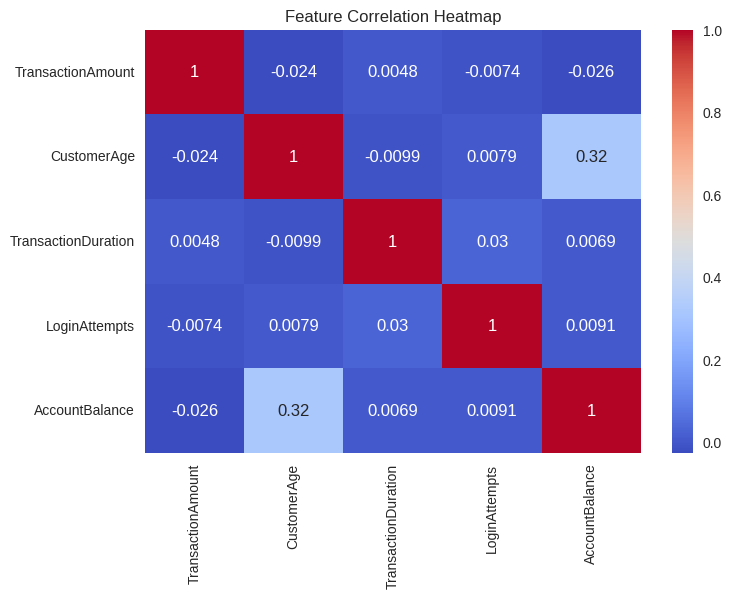

In [6]:
# Display correlation between numerical features
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# NOTES:
# The strongest positive correlation appears between CustomerAge and AccountBalance,
# indicating that older customers tend to have higher account balances.

### Distribution of Numerical Features

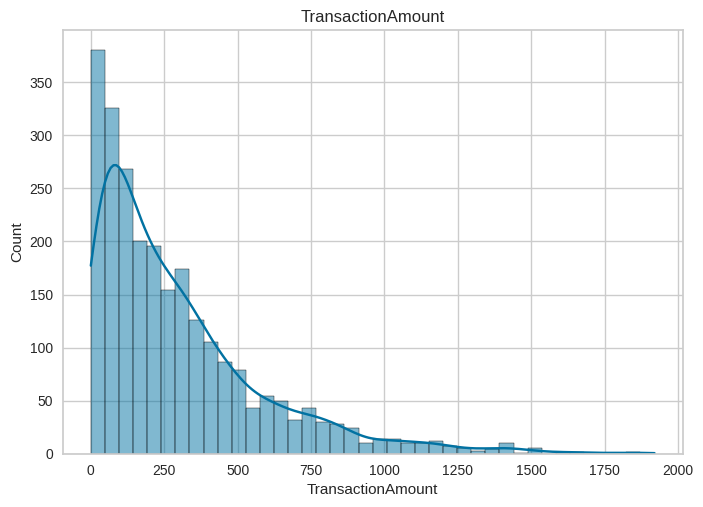

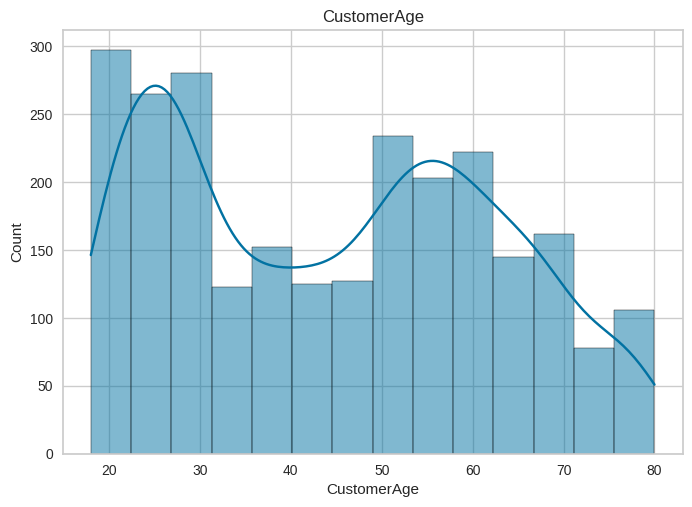

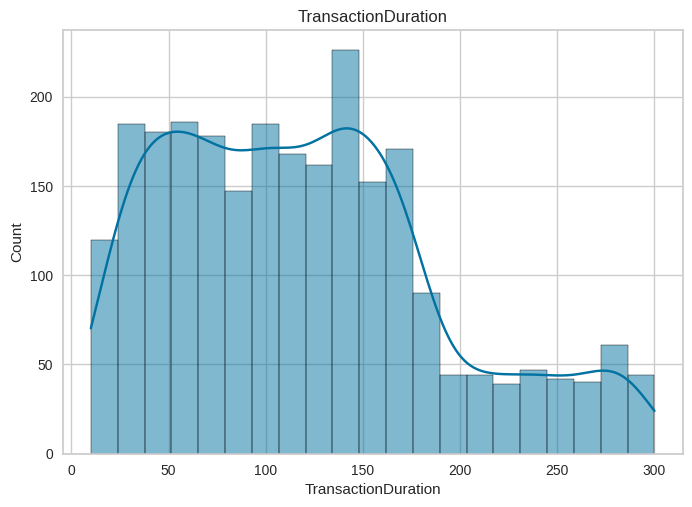

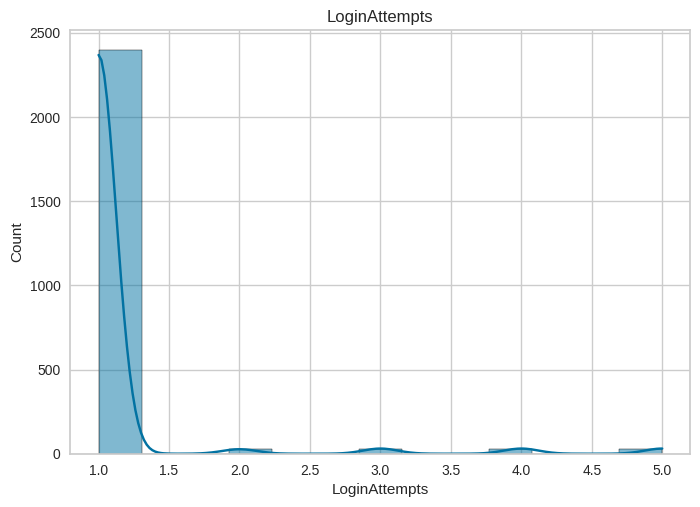

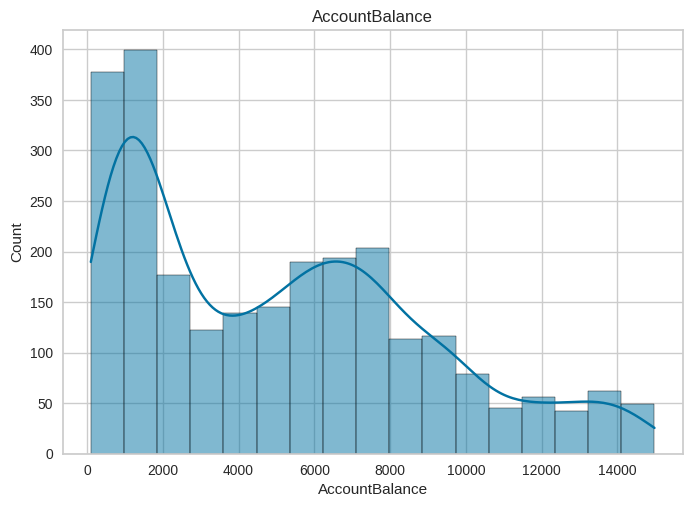

In [7]:
# Visualize the distribution of each numerical feature using histograms
for i in numeric_df:
  sns.histplot(numeric_df[i], kde=True)
  plt.title(i)
  plt.show()
  print('\n')

###Categorical Feature Distribution

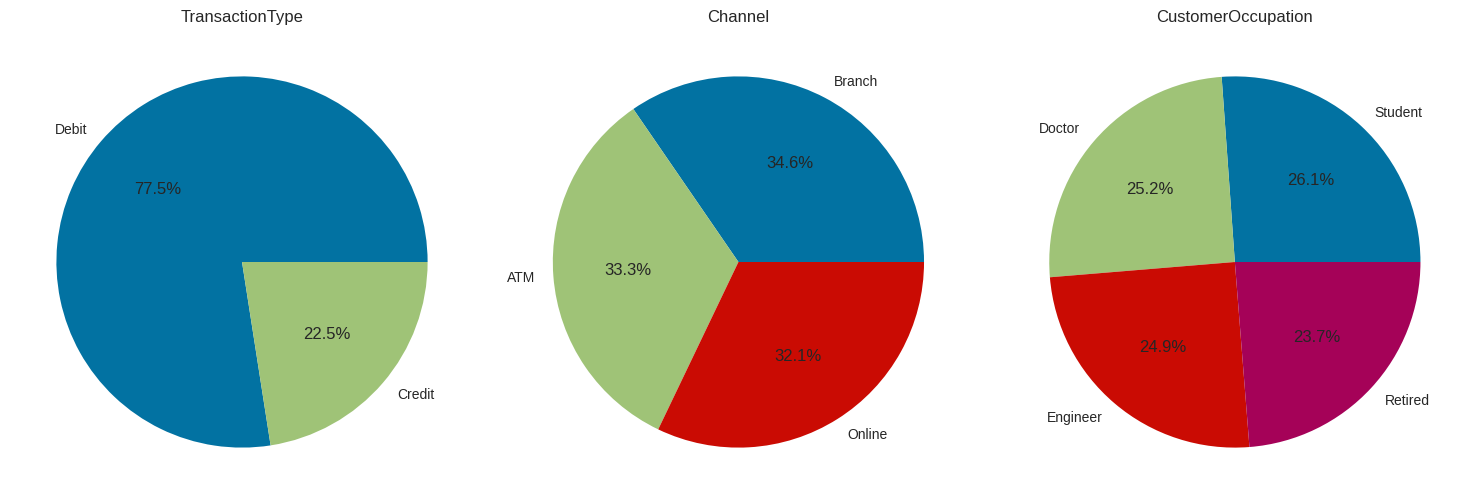

In [8]:
# Pie Chart for Categorical Features
categorical = df[["TransactionType", "Channel", "CustomerOccupation"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(categorical):
  counts = categorical[col].value_counts()
  axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%')
  axes[i].set_title(col)

plt.tight_layout()
plt.show()
print("\n")

### Outlier Detection

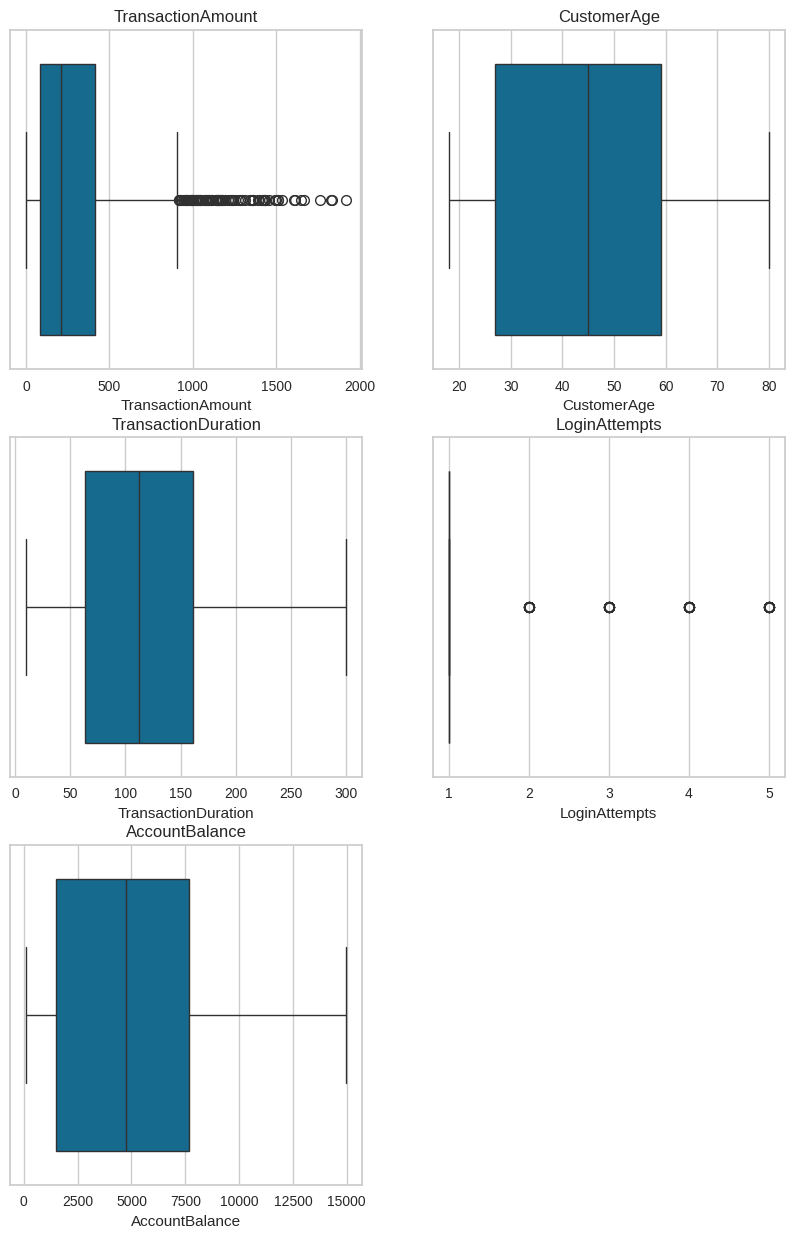

In [9]:
# Boxplot for outlier detection
row = round(len(numeric_df.columns)/2) + 1
fig, axes = plt.subplots(row, 2, figsize=(10, 5 * row))
axes = axes.flatten()

for i, fitur in enumerate(numeric_df.columns):
  sns.boxplot(x=df[fitur], ax = axes[i])
  axes[i].set_title(fitur)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

###Feature Relationship Analysis

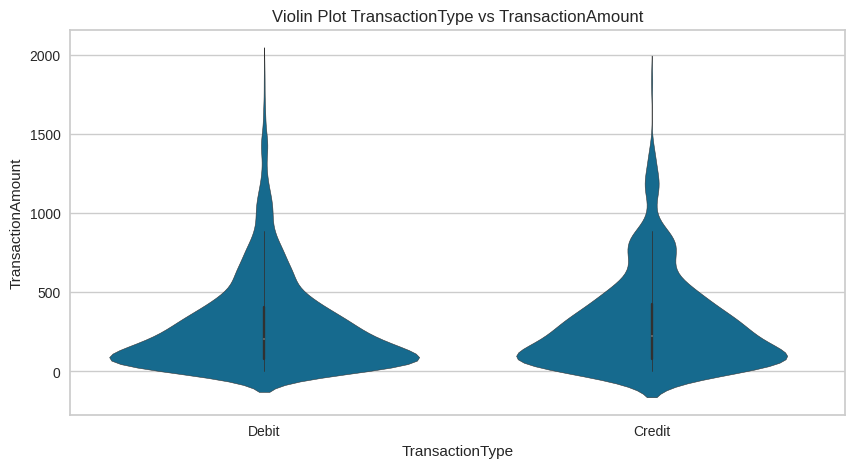

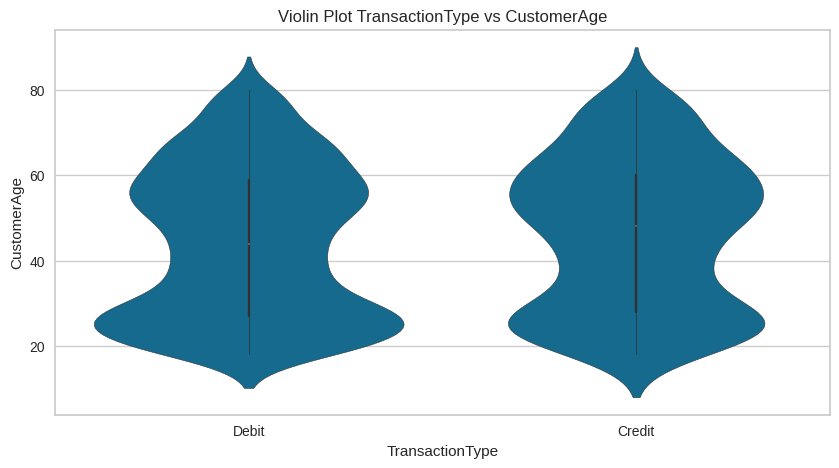

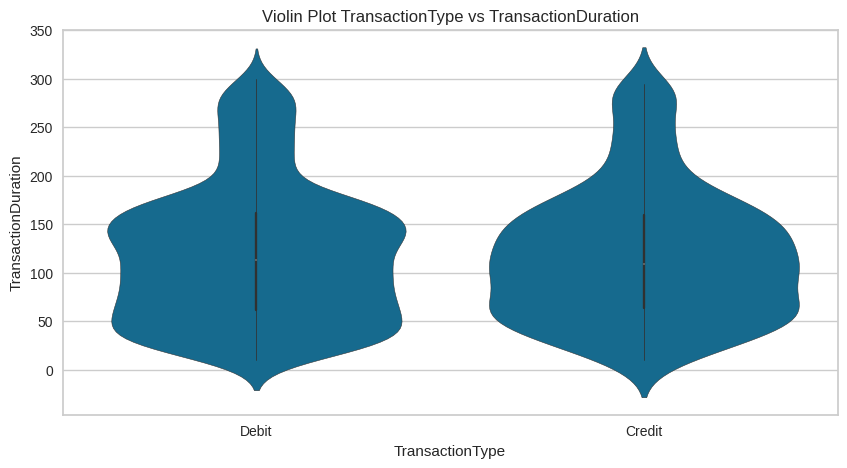

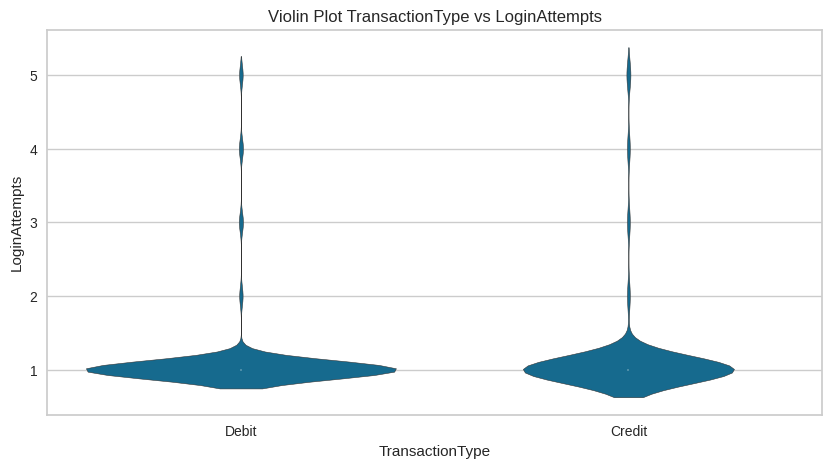

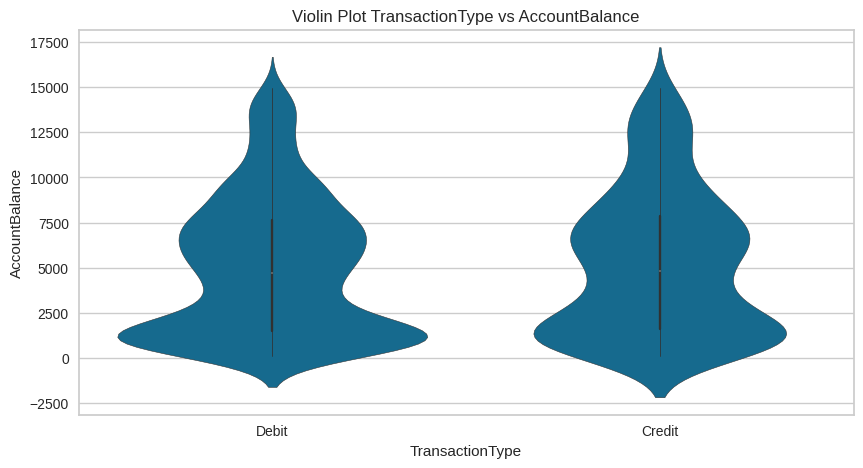

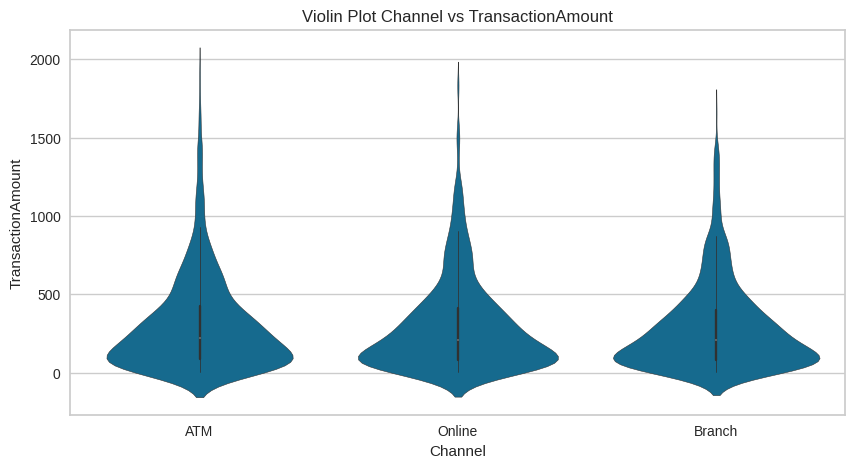

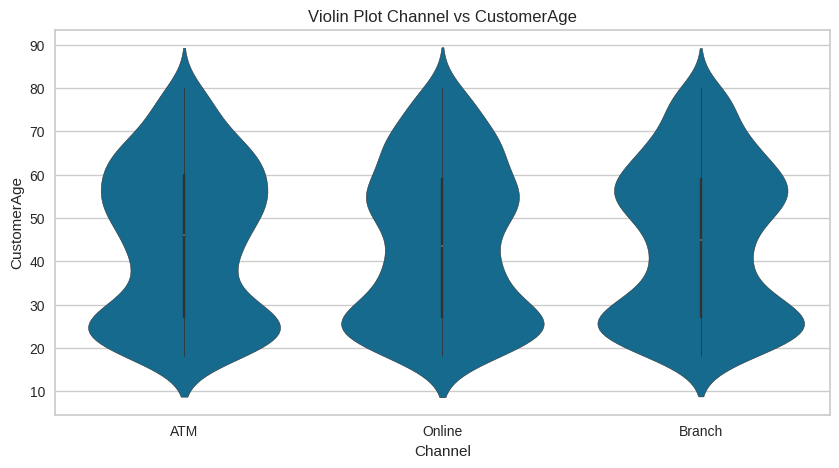

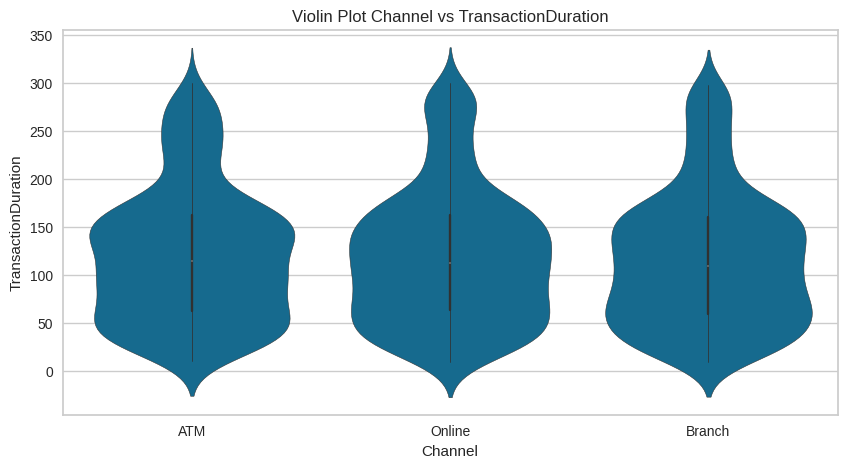

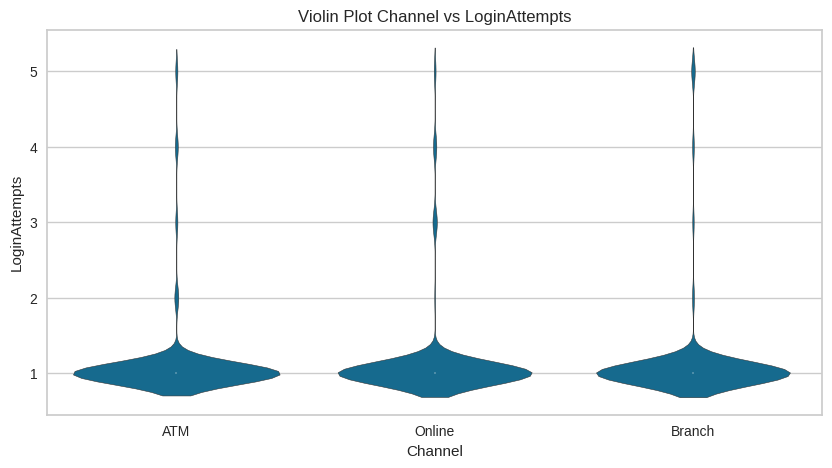

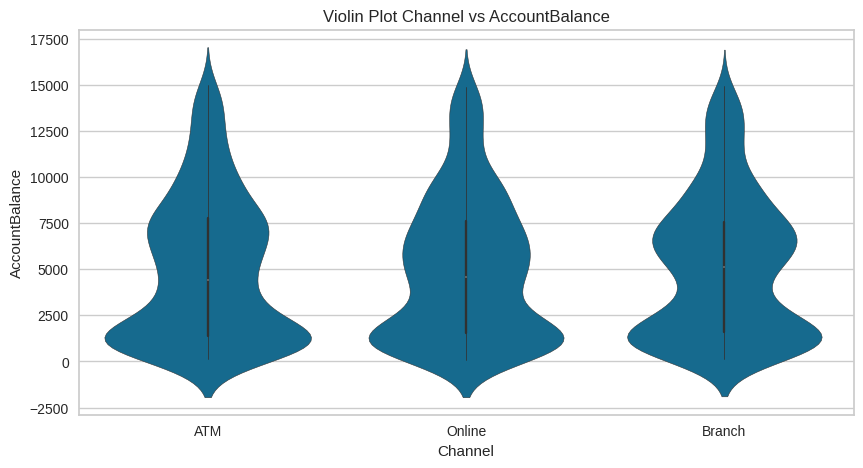

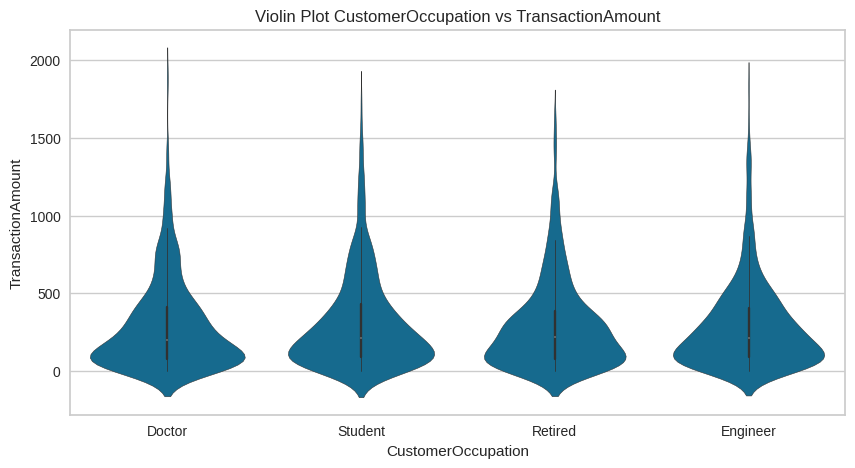

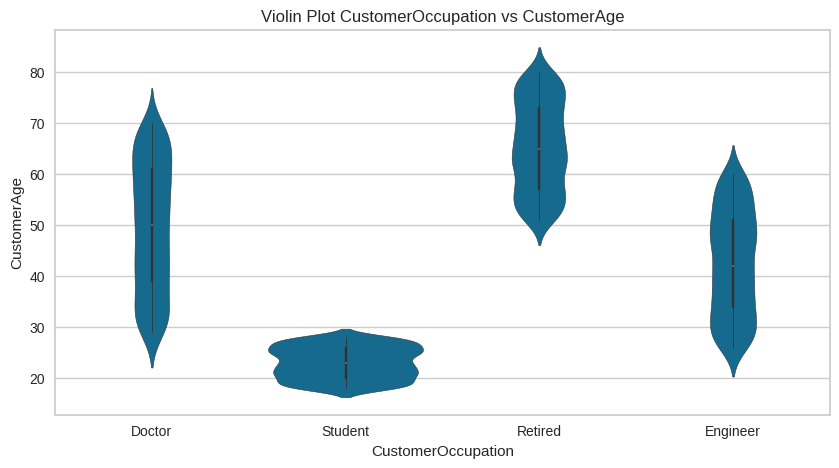

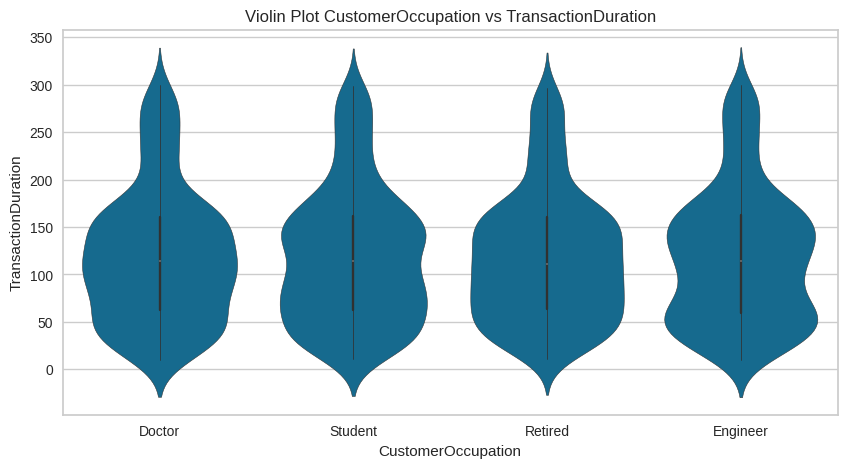

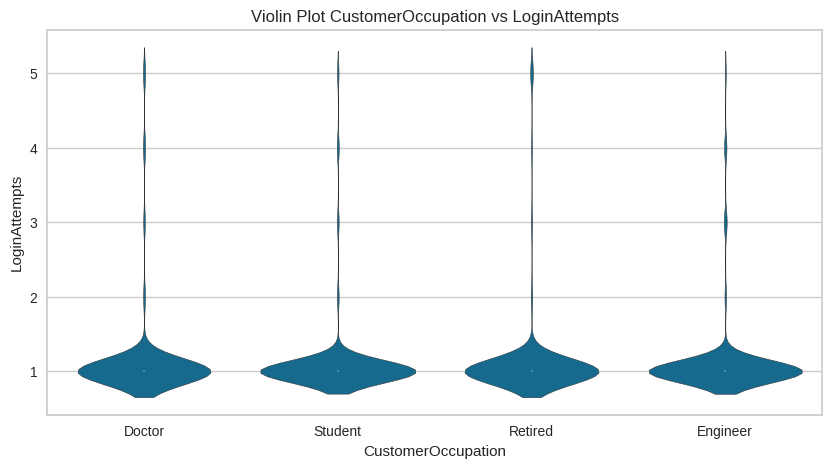

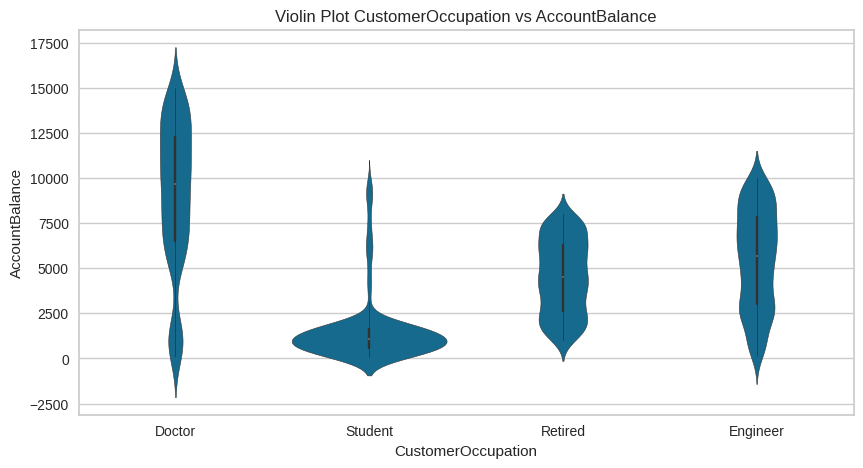

In [10]:
# Feature Relationship Analysis
for i in categorical:
  for j in numeric_df:

    plt.figure(figsize = (10,5))
    sns.violinplot(x=df[i], y=df[j])
    plt.title(f"Violin Plot {i} vs {j}")
    plt.xlabel(i)
    plt.ylabel(j)
    print("\n")
    plt.show()

## **4. Data Cleaning and Preprocessing**


### Data Checking

In [11]:
# Check for Missing values
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
TransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [12]:
# Check duplicated rows
df.duplicated().sum()

np.int64(21)

Scalling Numerical Data

In [13]:
# Fill missing values in each numerical column using the median
filled_num = numeric_df.copy()
for kolom in numeric_df.columns:
    median_kolom = numeric_df[kolom].median()
    filled_num[kolom].fillna(median_kolom, inplace=True)

# Normalize numerical features using Min-Max Scalling
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(filled_num[filled_num.columns])
df_scaled = pd.DataFrame(df_scaled, columns=filled_num.columns)

df[numeric_df.columns] = df_scaled
df_scaled.head()

/tmp/ipykernel_734/2668021930.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filled_num[kolom].fillna(median_kolom, inplace=True)


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
0,0.007207,0.838710,0.244828,0.0,0.336832
1,0.195940,0.806452,0.451724,0.0,0.918055
2,0.065680,0.016129,0.158621,0.0,0.068637
3,0.096016,0.129032,0.051724,0.0,0.569198
4,0.006874,0.435484,0.648276,0.0,0.492591


Drop Irrelevant Features dan Duplicated Columns

In [14]:
# Drop irrelevant features
df.drop(['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID'], axis = 1,inplace=True, errors='ignore')

print("\nRemaining Features:")
df.columns.to_list()


Remaining Features:


['TransactionAmount',
 'TransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'PreviousTransactionDate']

In [15]:
# Drop duplicated columns
df.drop_duplicates(inplace=True)

df.duplicated().sum()

np.int64(0)

### Encode Categorical Data

In [16]:
# Feature encoding using LabelEncoder for categorical features
categorical_df = df.select_dtypes(include=['object', 'category'])

# Fill missing values in categorical columns using mode
filled_cat = categorical_df.copy()
for kolom in categorical_df.columns:
    modus_kolom = categorical_df[kolom].mode()[0]
    filled_cat[kolom].fillna(modus_kolom, inplace=True)

encoders = {}
encode_df = pd.DataFrame()

# Encode categorical columns
for kolom in categorical_df.columns:
    df[kolom] = df[kolom].astype(str).str.strip()   # hapus spasi
    df[kolom].replace(['', ' ', 'nan', 'None', 'NaN'], np.nan, inplace=True)

    if df[kolom].isnull().sum() > 0:
        mode_val = df[kolom].mode()[0]
        df[kolom].fillna(mode_val, inplace=True)

    label_encoder = LabelEncoder()
    encode_df[kolom] = label_encoder.fit_transform(df[kolom])
    encoders[kolom] = label_encoder

df[categorical_df.columns] = encode_df

encode_df.describe()

/tmp/ipykernel_734/789532064.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filled_cat[kolom].fillna(modus_kolom, inplace=True)
/tmp/ipykernel_734/789532064.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,TransactionDate,TransactionType,Location,Channel,CustomerOccupation,PreviousTransactionDate
count,2514.000000,2514.000000,2514.000000,2514.000000,2514.000000,2514.000000
mean,1256.061655,0.776054,20.926014,0.989260,1.521082,179.113365
std,725.133396,0.416969,12.196727,0.804561,1.134662,102.458903
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,628.250000,1.000000,11.000000,0.000000,0.250000,91.250000
50%,1256.500000,1.000000,21.000000,1.000000,2.000000,178.000000
75%,1884.750000,1.000000,31.000000,2.000000,3.000000,269.000000
max,2484.000000,1.000000,42.000000,2.000000,3.000000,359.000000


In [17]:
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007207,680.0,1.0,36.0,0.0,0.838710,0.0,0.244828,0.0,0.336832,105.0
1,0.195940,1178.0,1.0,15.0,0.0,0.806452,0.0,0.451724,0.0,0.918055,192.0
2,0.065680,1262.0,1.0,23.0,2.0,0.016129,3.0,0.158621,0.0,0.068637,41.0
3,0.096016,818.0,1.0,33.0,2.0,0.129032,3.0,0.051724,0.0,0.569198,163.0
4,0.006874,1939.0,0.0,1.0,2.0,0.435484,3.0,0.648276,0.0,0.492591,16.0


### Outlier Handling

In [18]:
# Apply log transformation to reduce  the impact of outliers in the TransactionAmount feature
df['TransactionAmount'] = np.log1p(df['TransactionAmount'])

print("====HASIL HANDLING DENGAN LOG====\n")
df.describe()

====HASIL HANDLING DENGAN LOG====



,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2514.000000,2512.000000,2512.000000,2512.000000,2512.000000,2514.000000,2512.000000,2514.000000,2514.000000,2514.000000,2512.000000
mean,0.136101,1255.737659,0.776274,20.915207,0.989650,0.429415,1.520701,0.377490,0.030430,0.336864,179.180732
std,0.120530,724.981406,0.416824,12.194575,0.804639,0.286157,1.134683,0.240156,0.148674,0.260683,102.447290
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.042306,627.750000,1.000000,11.000000,0.000000,0.145161,0.000000,0.182759,0.000000,0.095324,91.750000
50%,0.104372,1256.500000,1.000000,21.000000,1.000000,0.435484,2.000000,0.351724,0.000000,0.311416,178.000000
75%,0.193367,1884.250000,1.000000,31.000000,2.000000,0.661290,3.000000,0.520690,0.000000,0.506870,269.000000
max,0.693147,2484.000000,1.000000,42.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000,359.000000


## **5. Build Clustering Model**

### Select Important Features

In [19]:
# Select relevant features for clustering analysis
# In this case, CustomerAge and AccountBalance are chosen

selected_feature = df.iloc[:, [5, 9]].values
df_selected = pd.DataFrame(selected_feature, columns=['CustomerAge', 'AccountBalance'])

print(df_selected)

      CustomerAge  AccountBalance
0        0.838710        0.336832
1        0.806452        0.918055
2        0.016129        0.068637
3        0.129032        0.569198
4        0.435484        0.492591
...           ...             ...
2509     0.612903        0.220590
2510     0.080645        0.112636
2511     0.096774        0.002017
2512     0.306452        0.442881
2513     0.145161        0.073593

[2514 rows x 2 columns]


Visualize Optimal Number of Clusters

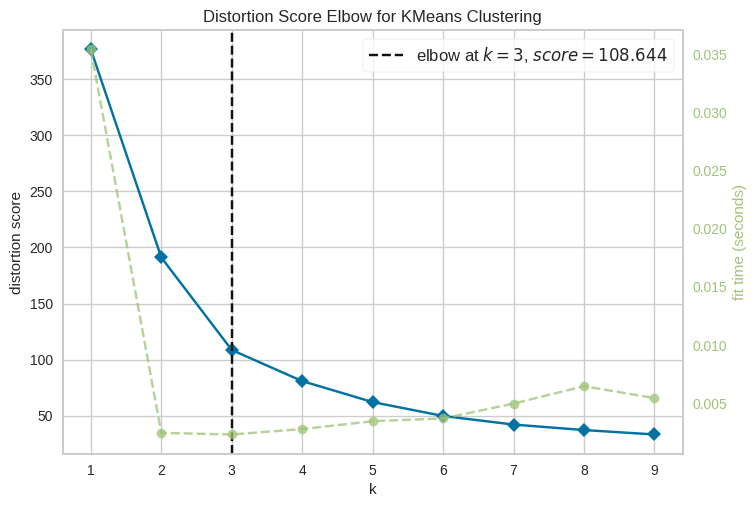

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Visualize the optimal number of clusters using the Elbow Method

kmeans = KMeans()
KElbow = KElbowVisualizer(KMeans(), k=(1,10))
KElbow.fit(selected_feature)
KElbow.show()

###Clustering

In [21]:
# Clustering using Kmeans Algorithm
k = 3
kmeans_vis = KMeans(n_clusters=k, random_state=0)
final_kmeans = kmeans_vis.fit(selected_feature)

labels = kmeans_vis.labels_

def analyze_clusters(selected_feature, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        cluster_data = selected_feature[labels == cluster_id]
        mean_Age = cluster_data[:, 0].mean()
        mean_Balance = cluster_data[:, 1].mean()
        print(f"\nCluster {cluster_id + 1}:")
        print(f"Customer age mean: {mean_Age:.2f}")
        print(f"Account balance mean: {mean_Balance:.2f}")

analyze_clusters(selected_feature, labels, k)

score = silhouette_score(selected_feature, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Customer age mean: 0.71
Account balance mean: 0.29

Cluster 2:
Customer age mean: 0.13
Account balance mean: 0.11

Cluster 3:
Customer age mean: 0.42
Account balance mean: 0.65

Silhouette Score: 0.48414385261680826


### Save Model

In [22]:
joblib.dump(final_kmeans, "model_clustering.h5")

['model_clustering.h5']

### Silhouette Score

In [23]:
scores = {}
for k in range(2, 10):
    Sil_kmeans = KMeans(n_clusters=k, random_state=42)
    Sil_labels = Sil_kmeans.fit_predict(selected_feature)
    score = silhouette_score(selected_feature, Sil_labels)
    scores[k] = score
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4523
K = 3, Silhouette Score = 0.4841
K = 4, Silhouette Score = 0.4799
K = 5, Silhouette Score = 0.4335
K = 6, Silhouette Score = 0.4527
K = 7, Silhouette Score = 0.4671
K = 8, Silhouette Score = 0.4445
K = 9, Silhouette Score = 0.4457


### Result Visualization

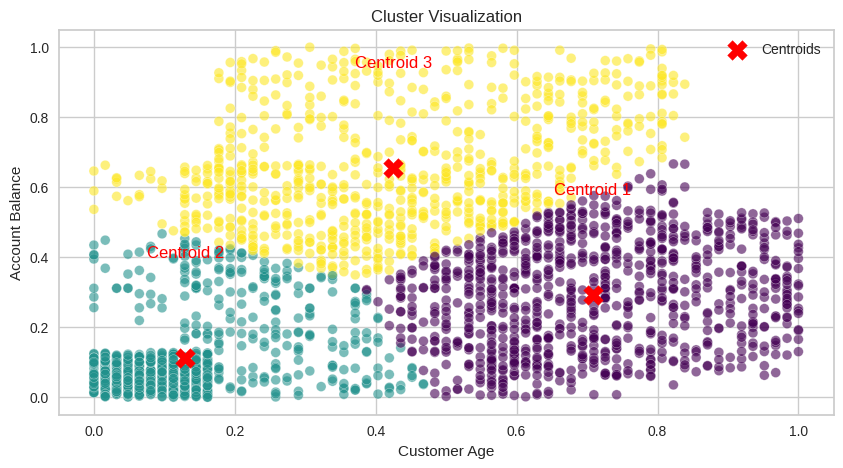

Nilai Centroids:
Centroid 1: Customer Age= 0.71, Account Balance = 0.29
Centroid 2: Customer Age= 0.13, Account Balance = 0.11
Centroid 3: Customer Age= 0.42, Account Balance = 0.65


In [24]:
centroids = kmeans_vis.cluster_centers_

plt.figure(figsize=(10, 5))
plt.scatter(selected_feature[:, 0], selected_feature[:, 1],
            c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=200, marker='X', label='Centroids')
for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1] + 0.3, f'Centroid {i+1}',
             color='red', fontsize=12, ha='center', va='center')

plt.title('Cluster Visualization')
plt.xlabel('Customer Age')
plt.ylabel('Account Balance')
plt.legend()

plt.show()

# Menampilkan nilai centroid
print("Nilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: Customer Age= {centroid[0]:.2f}, Account Balance = {centroid[1]:.2f}")


### Build Model with PCA

In [25]:
new_numeric = df.select_dtypes(include=['number'])

new_numeric = new_numeric.dropna()

pca = PCA(n_components=2)
data_pca = pca.fit_transform(new_numeric.values)
df_pca = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2'])
df_pca.head()

,PCA1,PCA2
0,-575.522301,-75.848482
1,-77.774698,12.611070
2,6.655512,-138.166887
3,-437.688086,-17.451081
4,683.720687,-161.195628


### Kmeans Clustering using PCA Data

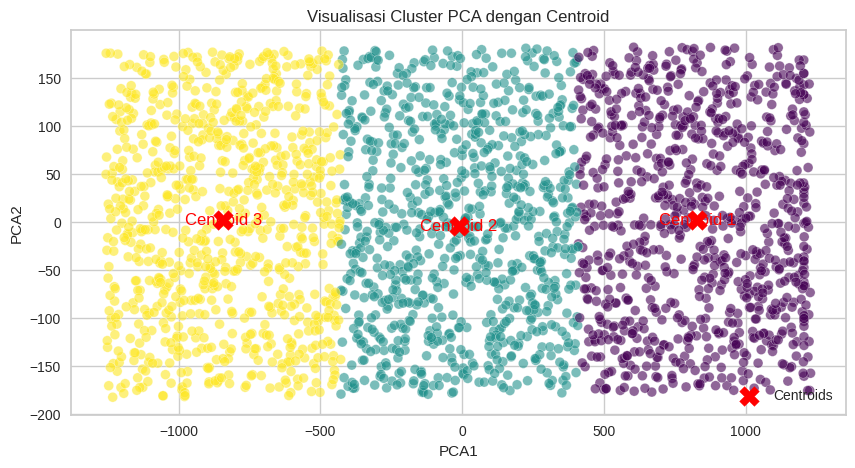

Nilai Centroids:
Centroid 1: PCA1= 830.03, PCA2 = 2.10
Centroid 2: PCA1= -11.27, PCA2 = -4.28
Centroid 3: PCA1= -842.75, PCA2 = 2.16

Silhouette Score: 0.5429554047944974


In [26]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
final_pca = kmeans_pca.fit(df_pca)

centroids_pca = final_pca.cluster_centers_

plt.figure(figsize=(10, 5))
plt.scatter(df_pca['PCA1'], df_pca['PCA2'],
            c=kmeans_pca.labels_, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', s=200, marker='X', label='Centroids')
for i, centroid in enumerate(centroids_pca):
    plt.text(centroid[0], centroid[1] + 0.2 , f'Centroid {i+1}',
             color='red', fontsize=12, ha='center', va='center')

plt.title('Visualisasi Cluster PCA dengan Centroid')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()

plt.show()

print("Nilai Centroids:")
for i, centroid in enumerate(centroids_pca):
    print(f"Centroid {i+1}: PCA1= {centroid[0]:.2f}, PCA2 = {centroid[1]:.2f}")

score = silhouette_score(df_pca, kmeans_pca.labels_)
print("\nSilhouette Score:", score)


### Save PCA Model

In [27]:
joblib.dump(final_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

## **5. Cluster Interpretation**

### Descriptive Analysis

In [28]:
df['Target'] = final_kmeans.labels_

stats = df.groupby('Target')[numeric_df.columns].agg(['mean','min','max']).round(2)

stats = stats.sort_index(axis=1, level=[0,1])
display(stats)

AccountBalance             CustomerAge             LoginAttempts        \
                  max  mean   min         max  mean   min           max  mean   
Target                                                                          
0                0.67  0.29  0.00        1.00  0.71  0.39           1.0  0.03   
1                0.47  0.11  0.00        0.47  0.13  0.00           1.0  0.03   
2                1.00  0.65  0.35        0.84  0.42  0.00           1.0  0.02   

            TransactionAmount            TransactionDuration             
        min               max  mean  min                 max  mean  min  
Target                                                                   
0       0.0              0.67  0.14  0.0                 1.0  0.37  0.0  
1       0.0              0.65  0.14  0.0                 1.0  0.38  0.0  
2       0.0              0.69  0.13  0.0                 1.0  0.38  0.0

## Cluster Characteristics Based on Feature Ranges (Before Inverse Scaling)

### 1. Cluster 1: (Older Customers with Low Account Balance)

- **Average Age**: *0.71*  
- **Minimum Age**: *0.39*  
- **Maximum Age**: *1*  

- **Average Account Balance**: *0.29*  
- **Minimum Balance**: *0*  
- **Maximum Balance**: *0.67*  

**Analysis:**  
This cluster represents older customers with relatively low account balances. These customers are likely individuals who are approaching retirement or are already retired. Their financial behavior suggests a preference for security and accessibility rather than high-risk financial growth.

Therefore, suitable banking products for this group include **basic savings accounts, pension-related services, and low-risk financial products** that help them manage their finances comfortably.

---

### 2. Cluster 2: (Young Customers with Low Account Balance)

- **Average Age**: *0.13*  
- **Minimum Age**: *0*  
- **Maximum Age**: *0.47*  

- **Average Account Balance**: *0.11*  
- **Minimum Balance**: *0*  
- **Maximum Balance**: *0.47*  

**Analysis:**  
This cluster represents younger customers with relatively low account balances. These individuals are likely students or early-career professionals whose financial stability is still developing.

Banking products suitable for this group include **low-cost savings accounts, accounts with no administrative fees, digital banking services, and promotional programs such as cashback, discounts, or integration with digital wallets**.

---

### 3. Cluster 3: (Middle-Aged Customers with Medium to High Account Balance)

- **Average Age**: *0.42*  
- **Minimum Age**: *0*  
- **Maximum Age**: *0.84*  

- **Average Account Balance**: *0.65*  
- **Minimum Balance**: *0.35*  
- **Maximum Balance**: *1*  

**Analysis:**  
This cluster represents middle-aged customers with medium to high account balances. These individuals are typically in their productive working years and have relatively stable financial conditions.

Appropriate banking products for this group include **time deposits, investment products, savings plans, and financial services that support long-term financial growth and wealth management**.

## **6. Export Data**

In [29]:
df.to_csv('data_clustering.csv', index=False)

In [30]:
# files.download('data_clustering.csv')
# files.download('model_clustering.h5')
# files.download('PCA_model_clustering.h5')

##**7. Inverse Dataset**

### Inverse Numerical Data

In [31]:
inversed_data = scaler.inverse_transform(df_scaled)
df_inversed = pd.DataFrame(inversed_data, columns=df_scaled.columns, index=df_scaled.index)

print("=== Inversed Data ===")
df_inversed.describe().round(2)

=== Inversed Data ===


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2537.00,2537.00,2537.00,2537.00,2537.00
mean,296.77,44.68,119.35,1.12,5109.40
std,290.86,17.77,69.72,0.59,3877.37
min,0.26,18.00,10.00,1.00,101.25
25%,83.07,27.00,63.00,1.00,1519.35
50%,211.36,45.00,112.00,1.00,4734.11
75%,409.61,59.00,161.00,1.00,7627.04
max,1919.11,80.00,300.00,5.00,14977.99


### Inverse Categorical Data

In [32]:
inversed_encode = pd.DataFrame()
for col in encode_df.columns:
     inversedCat = encoders[col]
     inversed_encode[col] = inversedCat.inverse_transform(encode_df[col].astype(int))

print("=== Inversed Data ===")
inversed_encode.head()

=== Inversed Data ===


,TransactionDate,TransactionType,Location,Channel,CustomerOccupation,PreviousTransactionDate
0,2023-04-11 16:29:14,Debit,San Diego,ATM,Doctor,2024-11-04 08:08:08
1,2023-06-27 16:44:19,Debit,Houston,ATM,Doctor,2024-11-04 08:09:35
2,2023-07-10 18:16:08,Debit,Mesa,Online,Student,2024-11-04 08:07:04
3,2023-05-05 16:32:11,Debit,Raleigh,Online,Student,2024-11-04 08:09:06
4,2023-10-16 17:51:24,Credit,Atlanta,Online,Student,2024-11-04 08:06:39


### Inversed Dataset

In [35]:
df[numeric_df.columns] = df_inversed[numeric_df.columns]
df[categorical_df.columns] = inversed_encode[categorical_df.columns]

columns_to_drop = []

for i in selected_feature:
  columns_to_drop.append(f"{i}_group_encode")

df.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,0
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,2
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,1
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,2
4,13.45,2023-10-16 17:51:24,Credit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 08:06:39,2


In [36]:
df.isnull().sum()

,0
TransactionAmount,0
TransactionDate,2
TransactionType,2
Location,2
Channel,2
CustomerAge,0
CustomerOccupation,2
TransactionDuration,0
LoginAttempts,0
AccountBalance,0


In [37]:
df.duplicated().sum()

np.int64(0)

### Descriptive Analysis for Inversed Dataset

In [38]:
inversed_stats = df.groupby('Target')[numeric_df.columns].agg(['mean','min','max']).round(2)

inversed_stats = inversed_stats.sort_index(axis=1, level=[0,1])
display(inversed_stats)


AccountBalance                   CustomerAge               \
                  max     mean      min         max   mean   min   
Target                                                             
0            10017.11  4458.55   120.89        80.0  61.90  42.0   
1             7047.04  1758.03   101.25        47.0  26.04  18.0   
2            14977.99  9841.01  5298.85        70.0  44.33  18.0   

       LoginAttempts            TransactionAmount                \
                 max  mean  min               max    mean   min   
Target                                                            
0                5.0  1.14  1.0           1830.00  295.92  0.84   
1                5.0  1.12  1.0           1762.28  304.52  0.26   
2                5.0  1.10  1.0           1919.11  289.49  0.32   

       TransactionDuration                
                       max    mean   min  
Target                                    
0                    299.0  117.56  10.0  
1                    300.0  120.37  10.0  
2                    300.0  120.84  10.0

In [39]:
essential_cat = ["TransactionType", "Channel", "CustomerOccupation"]
inversed_mode = df.groupby("Target")[essential_cat].agg(lambda x: x.mode()[0])

inversed_mode = inversed_mode.sort_index(axis=1, level=[0,1])
display(inversed_mode)

,Channel,CustomerOccupation,TransactionType
Target,,,
0,Branch,Retired,Debit
1,Branch,Student,Debit
2,Branch,Doctor,Debit


## Cluster Characteristics Based on Feature Ranges (After Inverse Scaling)

### 1. Cluster 1: (Older Customers with Low Account Balance)

- **Average Age**: *61.9*  
- **Minimum Age**: *41*  
- **Maximum Age**: *80*  

- **Average Account Balance**: *4458.55*  
- **Minimum Balance**: *120.89*  
- **Maximum Balance**: *10017.11*  

- **Dominant Occupation**: *Retired*

**Analysis:**  
This cluster represents older customers with relatively low savings balances. Most individuals in this cluster are retirees, meaning they are no longer actively working and typically have limited or fixed sources of income.

Therefore, the most suitable banking products for this group are **secure and easily accessible financial services**, such as **basic savings accounts, retirement funds, and financial management services tailored for retirees**.

---

### 2. Cluster 2: (Young Customers with Low Account Balance)

- **Average Age**: *26.04*  
- **Minimum Age**: *18*  
- **Maximum Age**: *47*  

- **Average Account Balance**: *1758.03*  
- **Minimum Balance**: *101.25*  
- **Maximum Balance**: *14977.99*  

- **Dominant Occupation**: *Student*

**Analysis:**  
This cluster consists of young customers with relatively low account balances. Many individuals in this group are students or early-stage professionals, which explains their limited income and relatively unstable financial conditions.

Appropriate banking products for this segment include **simple savings accounts with low requirements, accounts without administrative fees, and modern banking features such as cashback programs, discounts, and integration with digital wallets** that support their lifestyle needs.

---

### 3. Cluster 3: (Middle-Aged Customers with Medium to High Account Balance)

- **Average Age**: *44.33*  
- **Minimum Age**: *18*  
- **Maximum Age**: *70*  

- **Average Account Balance**: *9841.01*  
- **Minimum Balance**: *5298.85*  
- **Maximum Balance**: *6043.25*  

- **Dominant Occupation**: *Doctor*

**Analysis:**  
This cluster represents middle-aged customers with medium to high account balances. Many individuals in this segment work as professionals, such as doctors, which explains their relatively stable and higher financial capacity compared to other clusters.

Suitable banking products for this segment include **time deposits, investment products, long-term savings plans, and financial services that help them efficiently manage and grow their wealth despite their busy professional schedules**.

In [40]:
# Final Inversed Data
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,0
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,2
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,1
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,2
4,13.45,2023-10-16 17:51:24,Credit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 08:06:39,2


In [41]:
# Export Inversed Data
df.to_csv('data_clustering_inverse.csv', index=False)

In [42]:
files.download("data_clustering_inverse.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

End of Code.